In [1]:
import torch
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models.feature_extraction import create_feature_extractor
import torch.nn as nn
from torchvision.utils import make_grid
from torchvision.transforms.functional import to_pil_image

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import pairwise_distances

from lib.data.utils import Color
from lib.data.datasets import (
    ColoredMNISTDataset,
    get_ColoredMNISTDataset_dataloader
)
from lib.models.capacity_constrained_autoencoders import (
    ConfigBetaVAEForImages,
    BetaVAEForImages
)
from lib.analysis import tg_mds
from lib.plotting import fig_to_rgba
from lib import filepaths

device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [11]:
color_codes = [Color.RED, Color.GREEN, Color.CYAN, Color.YELLOW, Color.MAGENTA]

train_dataset = ColoredMNISTDataset(color_codes=color_codes, resize=32, train=True)
test_dataset = ColoredMNISTDataset(color_codes=color_codes, resize=32, train=False)

train_dataloader = get_ColoredMNISTDataset_dataloader(
    batch_size=64,
    dataset=train_dataset,
    drop_last=True, shuffle=True
)

test_dataloader = get_ColoredMNISTDataset_dataloader(
    batch_size=64,
    dataset=test_dataset,
    drop_last=True, shuffle=False
)

In [2]:
def load_model(ckpt):
    model = BetaVAEForImages(ckpt["config"])
    model.load_state_dict(ckpt["state_dict"])
    model.to(device)
    model.eval()
    return model

@torch.no_grad()
def get_reconstruction(cvae, pixel_values, label_id, feature_id, sigmoid=True):
    if isinstance(label_id, int):
        label_id = torch.tensor([label_id])
        feature_id = torch.tensor([feature_id])
    cvae.eval()
    pixel_values = pixel_values.to(device)
    sem_embed = cvae.sem_embeddings(label_id.to(device)).view(-1, *cvae.cond_hidden_shape)
    feat_embed = cvae.feat_embeddings(feature_id.to(device)).view(-1, *cvae.cond_hidden_shape)
    mu, logvar = cvae.encode(pixel_values)
    z = cvae._reparameterize(mu, logvar)
    rec = cvae.decode(z, sem_embed, feat_embed)

    if sigmoid == True:
        rec = torch.sigmoid(rec)
    else:
        rec = torch.clip(rec, 0, 1)

    return rec.cpu()

@torch.no_grad()
def get_feature_map(cvae, batch, last_layer=1):
    cvae.eval()
    batch.to(device)

    sem_embed = cvae.sem_embeddings(batch.label_ids).view(-1, *cvae.cond_hidden_shape)
    feat_embed = cvae.feat_embeddings(batch.feature_ids).view(-1, *cvae.cond_hidden_shape)

    mu, logvar = cvae.encode(batch.pixel_values)
    z = cvae._reparameterize(mu, logvar)

    cond = torch.cat([sem_embed, feat_embed], dim=1)
    feature_map = cvae.image_decoder(z, cond, verbose=last_layer)[1]

    f = nn.AdaptiveAvgPool2d((8,8))

    return f(feature_map).cpu().flatten(1).numpy()


@torch.no_grad()
def get_latent(cvae, batch):
    cvae.eval()
    batch.to(device)
    mu, _ = cvae.encode(batch.pixel_values)
    return mu.flatten(1).cpu().numpy()

In [3]:
root = "resources/image_beta_vae_capacity.pt"
ckpts = torch.load(root, weights_only=False)

capacities = list(ckpts.keys())

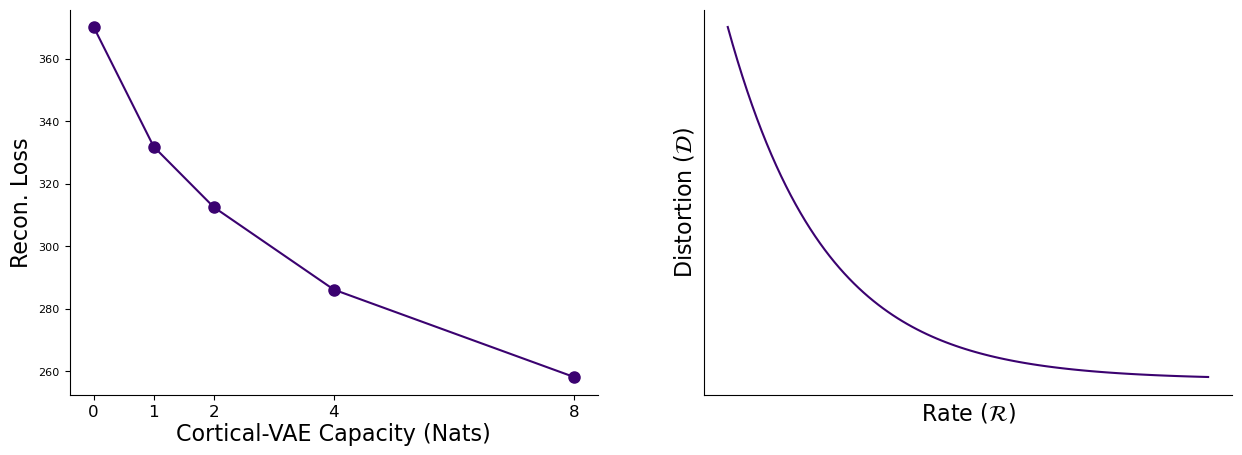

In [8]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

ax = axes[0]
Cs = capacities
ax.plot(Cs, [ckpts[i]["rec_loss"] for i in Cs], "o-", color="#3B0270", markersize=8)
ax.set_xticks(Cs)
ax.set_xlabel("Cortical-VAE Capacity (Nats)", fontsize=16, labelpad=2)
ax.set_ylabel("Recon. Loss", fontsize=16)
ax.set_xticklabels(Cs, fontsize=12)
ax.tick_params(axis="y", labelsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax = axes[1]
x = np.arange(100)
y = np.exp(-0.05*x)
ax.plot(x, y, "-", color="#3B0270")
ax.set_xticks([])
ax.set_yticks([])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("Rate " + r"$(\mathcal{R})$", fontsize=16, labelpad=5)
ax.set_ylabel("Distortion " + r"$(\mathcal{D})$", fontsize=16, labelpad=5)

fig.savefig("./visuals/cortical-vae-rate-distortion-curve.pdf")

In [12]:
latents = {k:None for k in capacities}
digit_ids = []
color_ids = []
done = False

for k in tqdm(latents):
    model = load_model(ckpts[k])

    hs = []
    for batch in test_dataloader:
        h = get_feature_map(model, batch, 3)
        hs.append(h)

        if not done:
            digit_ids.append(batch.label_ids.cpu().numpy())
            color_ids.append(batch.feature_ids.cpu().numpy())
    if not done:
        done = True

    latents[k] = np.vstack(hs)
digit_ids = np.hstack(digit_ids)
color_ids = np.hstack(color_ids)

100%|██████████| 5/5 [00:16<00:00,  3.37s/it]


In [34]:
n = 1000
np.random.seed(50)
pos = np.random.permutation(np.where(color_ids==0)[0])[:n]

Cs = [0,8]
x = np.vstack([latents[k][pos] for k in Cs])
rho = pairwise_distances(x, metric="cosine")
df_mds = pd.DataFrame(tg_mds(rho, 2))
df_mds.columns = ["MDS Dim 1", "MDS Dim 2"]
df_mds["Label"] = np.repeat(Cs, n)
df_mds["digit_id"] = np.tile(digit_ids[pos], len(Cs))
df_mds["color_id"] = np.tile(color_ids[pos], len(Cs))

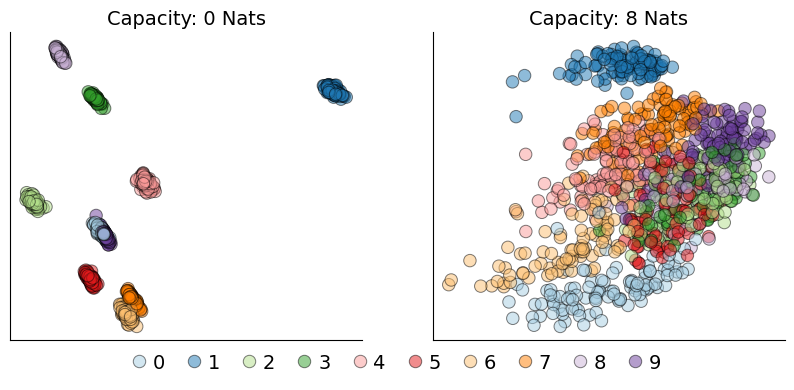

In [35]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
labels = ["0 Nats", "8 Nats"]
palette = "Paired"

ax = axes[0]
sns.scatterplot(
    data=df_mds.query("Label==0"),
    x="MDS Dim 1",
    y="MDS Dim 2",
    hue="digit_id",
    s=80, 
    edgecolor="black",
    palette=palette,
    alpha=0.5,
    ax=ax
)
ax.legend_.remove()
ax.set_title("Capacity: 0 Nats", fontsize=14)

###

ax = axes[1]
sns.scatterplot(
    data=df_mds.query("Label==8"),
    x="MDS Dim 1",
    y="MDS Dim 2",
    hue="digit_id",
    s=80, 
    edgecolor="black",
    palette=palette,
    alpha=0.5,
    ax=ax
)
ax.set_title("Capacity: 8 Nats", fontsize=14)

sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(-0.12, -0.16), ncol=10, 
    title=None, frameon=False,
    columnspacing=0.5,
    handletextpad=-0.3,
    fontsize=14
)

###

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

In [36]:
fig.savefig("visuals/mds-cortical-vae-capacity.pdf")

In [37]:
w = ResNet50_Weights.DEFAULT
preprocess = w.transforms()
model = resnet50(weights=w)
model.to(device)
model.eval()

model = create_feature_extractor(model, dict(layer1="feat1", layer2="feat2", layer3="feat3"))
f = nn.AdaptiveAvgPool2d((2,2))

@torch.no_grad()
def get_perc_emb(pixel_values):
    out = model(pixel_values.to(device))
    out = {k:f(v).flatten(1).cpu().numpy() for k,v in out.items()}
    return out

def vendi_score(rho):
    v = np.maximum(0, np.linalg.eigvalsh(rho/rho.shape[0]))
    vs = np.exp(-np.sum(v * np.log(v + 1e-17)))
    return vs

In [38]:
n = 50
df = test_dataset.data_table.copy()

table = []
for C in capacities:
    cvae = load_model(ckpts[C])
    
    for label_id in tqdm(range(10)):
        for feature_id in range(len(color_codes)):
            idx = pd.Series(df.query(f"label=={label_id} and color_id=={feature_id}").index)
            images = torch.stack([test_dataset[i][0] for i in idx.sample(n, replace=False)])

            recs = get_reconstruction(cvae, images, label_id, feature_id)

            out = get_perc_emb(recs)
            rho = {k:1 - pairwise_distances(v, metric="cosine") for k,v in out.items()}
            vs = {k:vendi_score(v) for k,v in rho.items()}
            vs["capacity"] = C

            table.append(vs)

table = pd.DataFrame(table)

100%|██████████| 10/10 [00:01<00:00,  6.66it/s]


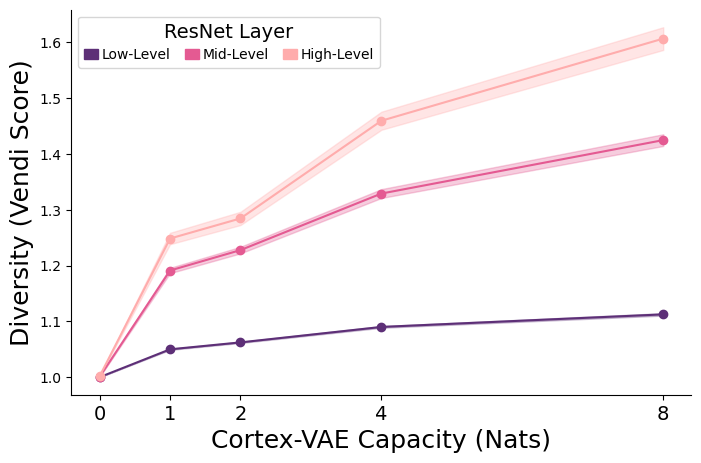

In [43]:
mean = table.groupby("capacity").mean().values.T
se = table.groupby("capacity").std()/np.sqrt(table.capacity.value_counts().values[0])
se = se.values.T

fig, ax = plt.subplots(1, figsize=(8,5))
labels = ["Low-Level", "Mid-Level", "High-Level"]
colors = ["#5D2F77", "#E45A92", "#FFACAC"]
palette = {k:v for k,v in zip(labels, colors)}
for i in range(len(mean)):
    t = capacities
    ax.plot(t, mean[i], "o-", label=labels[i], color=colors[i])
    ax.fill_between(t, mean[i]-se[i], mean[i]+se[i], alpha=0.3, color=colors[i])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.set_xticks(ticks=t, labels=capacities, fontsize=14)
ax.set_xlabel("Cortex-VAE Capacity (Nats)", fontsize=18)
ax.set_ylabel("Diversity (Vendi Score)", fontsize=18)

leg = ax.legend(
    handles=[Patch(color=v, label=k) for k,v in palette.items()],
    loc="upper left",
    ncol=3,
    handlelength=1,
    handletextpad=0.3,
    columnspacing=1.0,
)
leg.set_title("ResNet Layer", prop={'size': 14})

In [44]:
fig.savefig("visuals/cortical-vae-vendi_score.pdf")